In [1]:
%reset -f

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
!{sys.executable} -m pip install openpyxl
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy openpyxl numpy

In [4]:
import pandas as pd
#pathname = "/Users/nxmai0309/Documents/My project/Online Retail.xlsx"
#pathname2 = "/Users/nxmai0309/Documents/My project/Online Retail 2.xlsx"
#raw1 = pd.read_excel(pathname)
#raw2 = pd.read_excel(pathname2)
pathname = "/Users/nxmai0309/Documents/My project/Online Retail.csv"
pathname2 = "/Users/nxmai0309/Documents/My project/Online Retail 2.csv"
raw1 = pd.read_csv(pathname)
raw2 = pd.read_csv(pathname2)
df = pd.concat([raw2, raw1], ignore_index=True)
print(df.shape)
print(df.dtypes)
print(df.info())
#df_raw = pd.read_csv("online_retail_combined.csv", parse_dates=['InvoiceDate'])

(1083818, 8)
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1083818 entries, 0 to 1083817
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   InvoiceNo    1083818 non-null  str    
 1   StockCode    1083818 non-null  str    
 2   Description  1080910 non-null  str    
 3   Quantity     1083818 non-null  int64  
 4   InvoiceDate  1083818 non-null  str    
 5   UnitPrice    1083818 non-null  float64
 6   CustomerID   813658 non-null   float64
 7   Country      1083818 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.2 MB
None


In [13]:
# Look at StockCodes that don't follow the normal 5-digit pattern
non_numeric = df[~df['StockCode'].astype(str).str.match(r'^\d{5}[a-zA-Z]?$')]
print(non_numeric['StockCode'].value_counts().head(20))

df['has_customer_id'] = df['CustomerID'].notna()

comparison = df.groupby('has_customer_id').agg(
    row_count=('InvoiceNo', 'size'),
    revenue=('UnitPrice', lambda x: (x * df.loc[x.index, 'Quantity']).sum()),
    avg_quantity=('Quantity', 'mean'),
    avg_price=('UnitPrice', 'mean'),
    unique_invoices=('InvoiceNo', 'nunique'),
    unique_products=('StockCode', 'nunique')
).round(2)

print(comparison)

StockCode
DOT             709
M               277
15056BL         259
15056bl          62
POST             56
C2               31
DCGSSGIRL        13
BANK CHARGES     12
DCGSSBOY         11
gift_0001_20     10
gift_0001_10      9
gift_0001_30      8
DCGS0003          4
gift_0001_50      4
PADS              4
gift_0001_40      3
AMAZONFEE         2
DCGS0076          2
S                 2
DCGS0070          1
Name: count, dtype: int64
                 row_count     revenue  avg_quantity  avg_price  \
has_customer_id                                                   
False               131914  1716719.45          3.52       6.20   
True                349406  7288605.03         12.18       2.97   

                 unique_invoices  unique_products  
has_customer_id                                    
False                       2135             3539  
True                       16654             3645  


In [14]:
# Flag cancellations (Invoice starts with 'C')
df['is_cancellation'] = df['InvoiceNo'].astype(str).str.startswith('C')

# Store cancellations separately for potential feature engineering later
df_cancellations = df[df['is_cancellation']].copy()
print(f"Cancellation rows: {len(df_cancellations):,}")

# Keep only non-cancellation transactions for main analysis
df_clean = df[~df['is_cancellation']].copy()
print(f"Rows after removing cancellations: {len(df_clean):,}")

Cancellation rows: 0
Rows after removing cancellations: 481,320


In [23]:
non_product_codes = non_numeric['StockCode'].values.tolist()
non_product_mask = (
    df['StockCode'].astype(str).isin(non_product_codes) |
    df['StockCode'].astype(str).str.match(r'^[A-Za-z]+$')
)
df = df[~non_product_mask].copy()

In [25]:
# E-commerce Data Cleaning

# Null analysis
df['Missing'] = df["CustomerID"].isna()
print(len(df))
#print(df['missing'])
df['Revenue'] = df["Quantity"]*df["UnitPrice"]
check = df.groupby("Missing").agg({"Revenue":"sum", "InvoiceNo":"count"})
#print(check)
#print(df["CustomerID"].isna().sum()/len(df["CustomerID"]))
#print(135080/(406829+135080))
#print(1447682.120/(1447682.120+8300065.814))
# => null-customer IDs represent 25% of rows, but only 15% of revenue hence dropping nulls in modelling does not create any
df = df[df['CustomerID'].notna()].copy()

# Duplicate analysis
dupes = df.duplicated().sum()
print(dupes)
df = df.drop_duplicates()
# Data range adjustment
df_returns = df[df['Quantity'] < 0].copy()
df = df[df["Quantity"]>=0]
df = df[df["UnitPrice"]>=0]
df = df[(df["Country"] == "United Kingdom") | (df["Country"] == "USA")]
#print(f"Quantity range: {df['Quantity'].min()} to {df['Quantity'].max()}")
#print(f"Price range: {df['UnitPrice'].min()} to {df['UnitPrice'].max()}")
#print(f"Negative quantity rows: {(df['Quantity'] < 0).sum():,}")
#print(f"Zero price rows: {(df['UnitPrice'] == 0).sum():,}")
#print(f"Negative price rows: {(df['UnitPrice'] < 0).sum():,}")

# Data type analysis
print(df.dtypes)
print(df['InvoiceDate'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')
df['CustomerID'] = df['CustomerID'].astype('str')
#for col in df.columns.tolist():
#    print(col)
#    print(df[col].unique())


479837
0
InvoiceNo                     str
StockCode                     str
Description                   str
Quantity                    int64
InvoiceDate        datetime64[us]
UnitPrice                 float64
CustomerID                    str
Country                       str
Missing                      bool
Revenue                   float64
hour                        int32
day_of_week                   str
month                       int32
has_customer_id              bool
is_cancellation              bool
dtype: object
0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541889   2011-12-09 12:31:00
541890   2011-12-09 12:49:00
541891   2011-12-09 12:49:00
541892   2011-12-09 12:49:00
541893   2011-12-09 12:49:00
Name: InvoiceDate, Length: 348842, dtype: datetime64[us]


Date range: 2010-12-01 08:26:00 to 2011-12-09 12:49:00
Total customers: 3,925
Total invoices: 18,789
Total revenue: £9,005,324
Avg revenue per customer: £1,856.97
Avg invoices per customer: 4.2


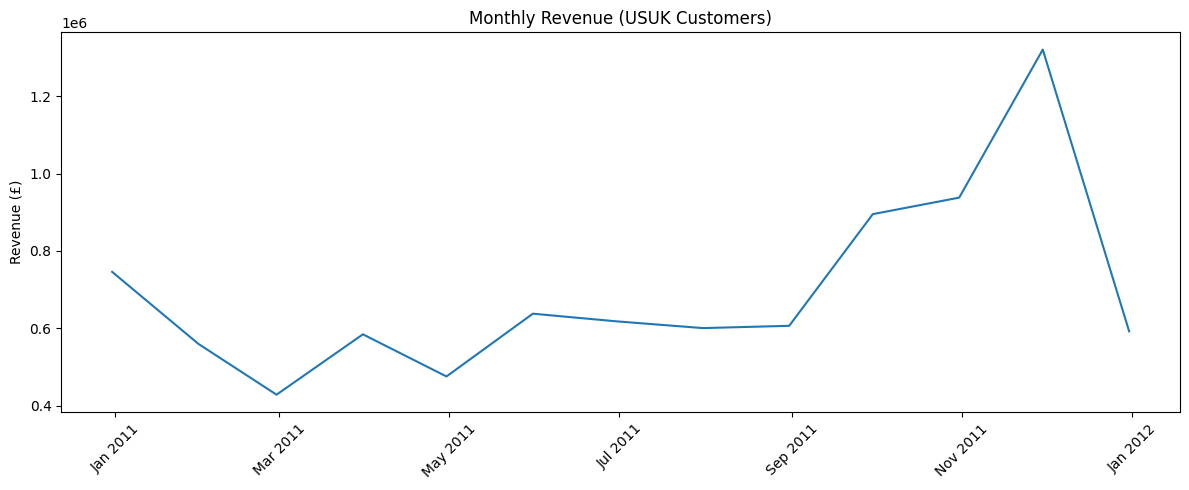

Top 10% of customers generate 59.7% of revenue


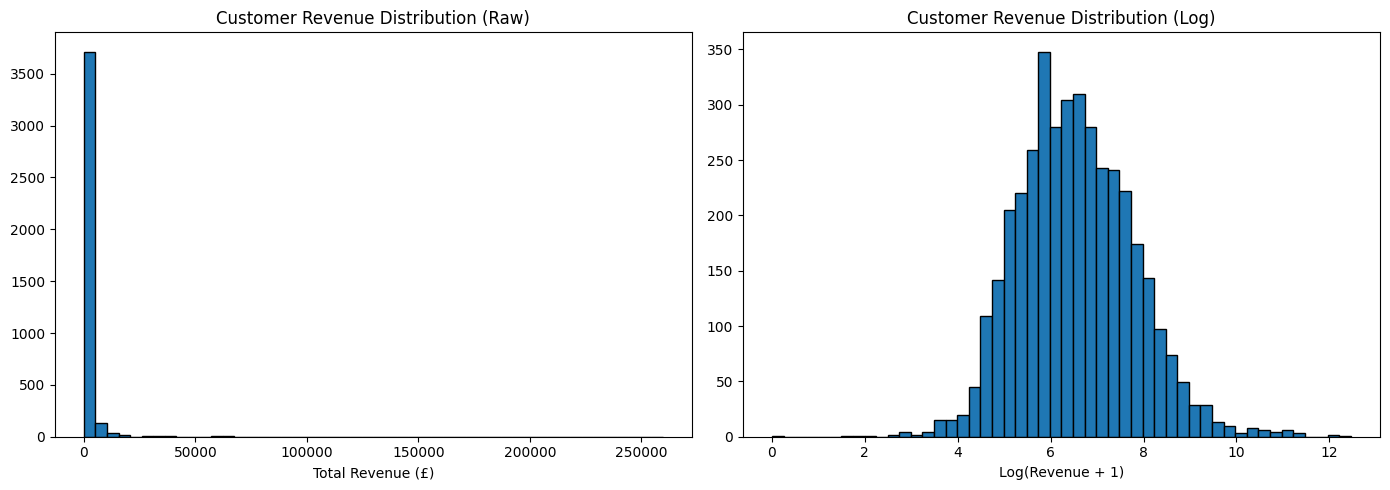

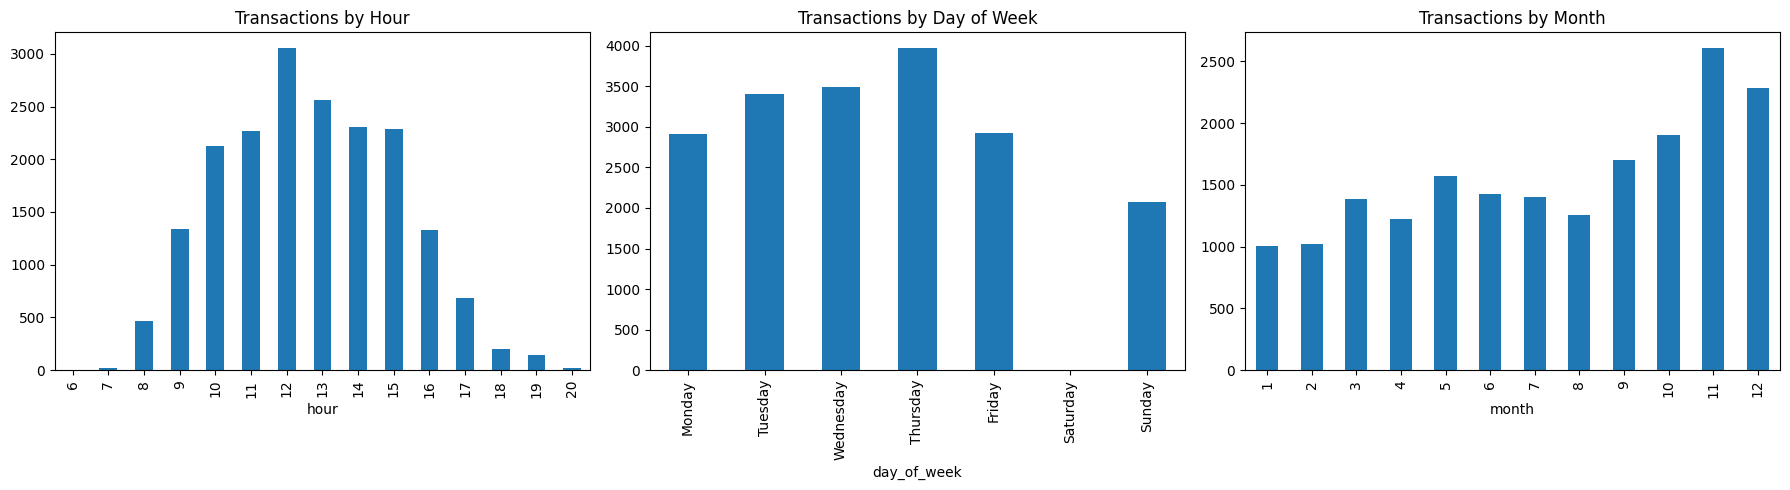

Median purchases per customer: 2.0
Mean purchases per customer: 4.2
One-time buyers: 1354 (34.5%)


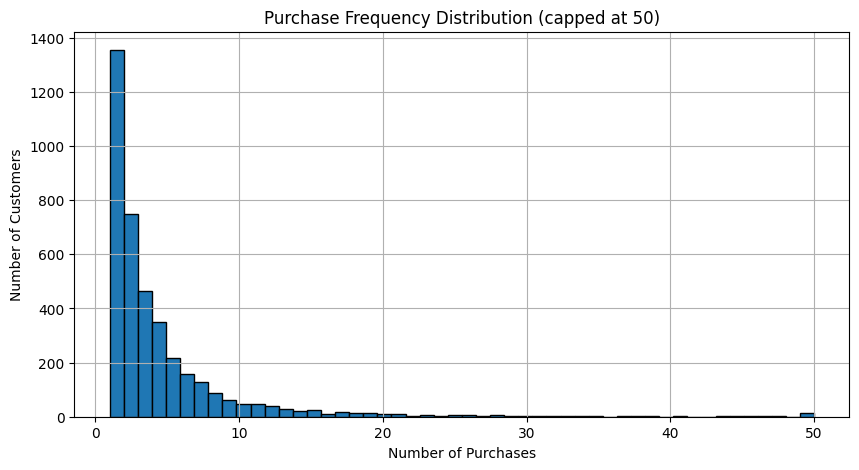

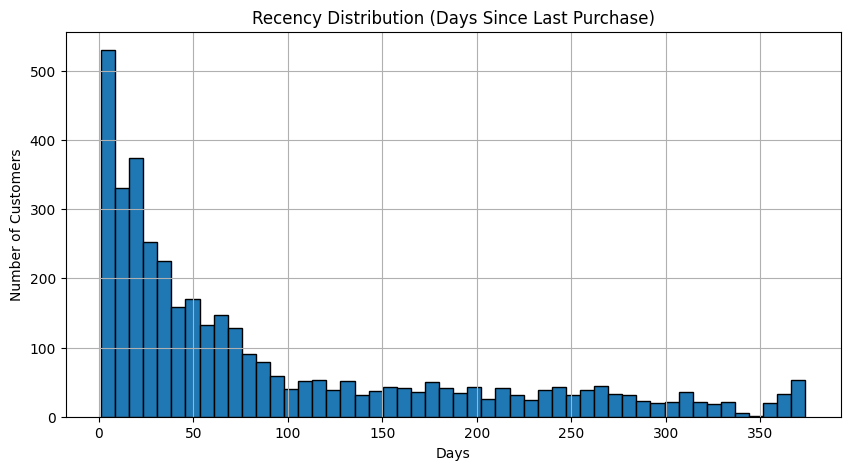

Median recency: 51 days
Customers with recency > 180 days: 776 (19.8%)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total customers: {df['CustomerID'].nunique():,}")
print(f"Total invoices: {df['InvoiceNo'].nunique():,}")
print(f"Total revenue: £{df['Revenue'].sum():,.0f}")
print(f"Avg revenue per customer: £{df.groupby('CustomerID')['Revenue'].sum().mean():,.2f}")
print(f"Avg invoices per customer: {df.groupby('CustomerID')['InvoiceNo'].nunique().mean():.1f}")

monthly_revenue = (
    df
    .set_index('InvoiceDate')
    .resample('ME')['Revenue']
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values)
ax.set_title('Monthly Revenue (USUK Customers)')
ax.set_ylabel('Revenue (£)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

# Top 10% of customers
top_10_pct = int(len(customer_revenue) * 0.10)
top_10_revenue = customer_revenue.head(top_10_pct).sum()
total_revenue = customer_revenue.sum()
print(f"Top 10% of customers generate {top_10_revenue/total_revenue*100:.1f}% of revenue")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(customer_revenue, bins=50, edgecolor='black')
axes[0].set_title('Customer Revenue Distribution (Raw)')
axes[0].set_xlabel('Total Revenue (£)')

axes[1].hist(np.log1p(customer_revenue), bins=50, edgecolor='black')
axes[1].set_title('Customer Revenue Distribution (Log)')
axes[1].set_xlabel('Log(Revenue + 1)')

plt.tight_layout()
plt.show()

df['hour'] = df['InvoiceDate'].dt.hour
df['day_of_week'] = df['InvoiceDate'].dt.day_name()
df['month'] = df['InvoiceDate'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly
df.groupby('hour')['InvoiceNo'].nunique().plot(kind='bar', ax=axes[0])
axes[0].set_title('Transactions by Hour')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('day_of_week')['InvoiceNo'].nunique().reindex(day_order).plot(kind='bar', ax=axes[1])
axes[1].set_title('Transactions by Day of Week')

# Monthly
df.groupby('month')['InvoiceNo'].nunique().plot(kind='bar', ax=axes[2])
axes[2].set_title('Transactions by Month')

plt.tight_layout()
plt.show()

customer_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
print(f"Median purchases per customer: {customer_frequency.median()}")
print(f"Mean purchases per customer: {customer_frequency.mean():.1f}")
print(f"One-time buyers: {(customer_frequency == 1).sum()} ({(customer_frequency == 1).mean()*100:.1f}%)")
fig, ax = plt.subplots(figsize=(10, 5))
customer_frequency.clip(upper=50).hist(bins=50, edgecolor='black', ax=ax)
ax.set_title('Purchase Frequency Distribution (capped at 50)')
ax.set_xlabel('Number of Purchases')
ax.set_ylabel('Number of Customers')
plt.show()

# Reference date: last date in dataset + 1 day
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_recency = (
    reference_date - df.groupby('CustomerID')['InvoiceDate'].max()
).dt.days

fig, ax = plt.subplots(figsize=(10, 5))
customer_recency.hist(bins=50, edgecolor='black', ax=ax)
ax.set_title('Recency Distribution (Days Since Last Purchase)')
ax.set_xlabel('Days')
ax.set_ylabel('Number of Customers')
plt.show()

print(f"Median recency: {customer_recency.median():.0f} days")
print(f"Customers with recency > 180 days: {(customer_recency > 180).sum()} ({(customer_recency > 180).mean()*100:.1f}%)")


"""
## EDA Key Findings

1. **Business profile:** UK gift-ware wholesaler, B2B dominant, 
   weekday-only operations, strong November seasonality
2. **Customer base:** X,XXX unique registered UK customers
3. **Revenue concentration:** Top 10% of customers generate XX% of revenue
4. **Purchase frequency:** XX% are one-time buyers, median X purchases
5. **Recency:** Median XX days, XX% inactive >180 days
6. **Survivorship bias:** Null-CustomerID transactions are [similar/different] 
   to identified transactions in [dimensions]
7. **Implications for modelling:**
   - Heavy right skew in all monetary features → log transform needed
   - High one-time buyer rate → churn definition must account for this
   - Strong seasonality → temporal split must respect seasonal patterns
   - Revenue concentration → CLV model must handle outliers
"""